In [12]:
# import cobra as cb # Pretty slow
import polars as pl 
import pandas as pd
import polars.selectors as cs
from scipy.io import loadmat
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


# Gene Expression Data Analysis

In [13]:
ge_df = pl.read_csv("../../data/rnaseq/tpm_avg_recon.tsv", separator="\t").with_columns(
    GeneID=pl.col("GeneID").cast(pl.Utf8),
    # index = pl.int_range(pl.len())
).rename(
    {'GES_W1':'GES_WT'}
).select(
    sorted(["GeneID", "GES_WT", "GES1_ARID1A_KO", "GES1_WT_Volasertib", "GES1_ARID1A_KO_Volasertib", "OVCAR3_WT", "OVCAR3_ARID1A_KO"])
)
ge_df.head()

GES1_ARID1A_KO,GES1_ARID1A_KO_Volasertib,GES1_WT_Volasertib,GES_WT,GeneID,OVCAR3_ARID1A_KO,OVCAR3_WT
f64,f64,f64,f64,str,f64,f64
0.06759,0.10198,0.070905,0.10272,"""100287102.0""",0.645,0.10554
18.745,17.25,18.625,18.605,"""653635.0""",25.52,21.455
9.852,14.047,10.4835,8.3455,"""102466751.0""",15.7355,7.8665
0.0,0.0,0.09955,0.1035,"""107985730.0""",0.0,0.16205
0.0,0.0,0.0,0.0,"""100302278.0""",0.4057,0.0


In [14]:
sorted(["GeneID", "GES_WT", "GES1_ARID1A_KO", "GES1_WT_Volasertib", "GES1_ARID1A_KO_Volasertib", "OVCAR3_WT", "OVCAR3_ARID1A_KO"])

['GES1_ARID1A_KO',
 'GES1_ARID1A_KO_Volasertib',
 'GES1_WT_Volasertib',
 'GES_WT',
 'GeneID',
 'OVCAR3_ARID1A_KO',
 'OVCAR3_WT']

In [15]:
ge_df = ge_df.to_pandas().set_index("GeneID")
ge_df

,GES1_ARID1A_KO,GES1_ARID1A_KO_Volasertib,GES1_WT_Volasertib,GES_WT,OVCAR3_ARID1A_KO,OVCAR3_WT
GeneID,,,,,,
100287102.0,0.06759,0.10198,0.070905,0.10272,0.6450,0.10554
653635.0,18.74500,17.25000,18.625000,18.60500,25.5200,21.45500
102466751.0,9.85200,14.04700,10.483500,8.34550,15.7355,7.86650
107985730.0,0.00000,0.00000,0.099550,0.10350,0.0000,0.16205
100302278.0,0.00000,0.00000,0.000000,0.00000,0.4057,0.00000
...,...,...,...,...,...,...
4541.1,3824.50000,3986.00000,3775.500000,4119.00000,3143.0000,3195.00000
4556.0,1740.00000,1871.50000,2003.500000,2259.00000,1786.0000,1897.00000
4519.1,4738.00000,4804.50000,3269.000000,3646.50000,5278.5000,4499.50000


In [16]:
# from scipy.stats import pearsonr

corr_mat = ge_df.corr()

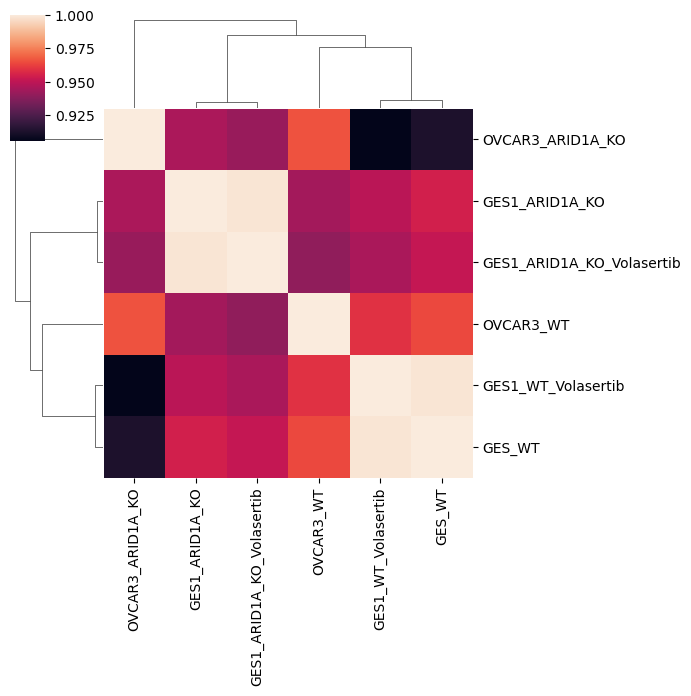

In [17]:
# fig, ax = plt.subplots(figsize=(7,7))
sns.clustermap(corr_mat, figsize=(7,7), )
plt.savefig("../../results/model_evalutation/gene_expression_correlation.svg", dpi=300, bbox_inches='tight')

In [18]:
ge_df.T.index

Index(['GES1_ARID1A_KO', 'GES1_ARID1A_KO_Volasertib', 'GES1_WT_Volasertib',
       'GES_WT', 'OVCAR3_ARID1A_KO', 'OVCAR3_WT'],
      dtype='object')

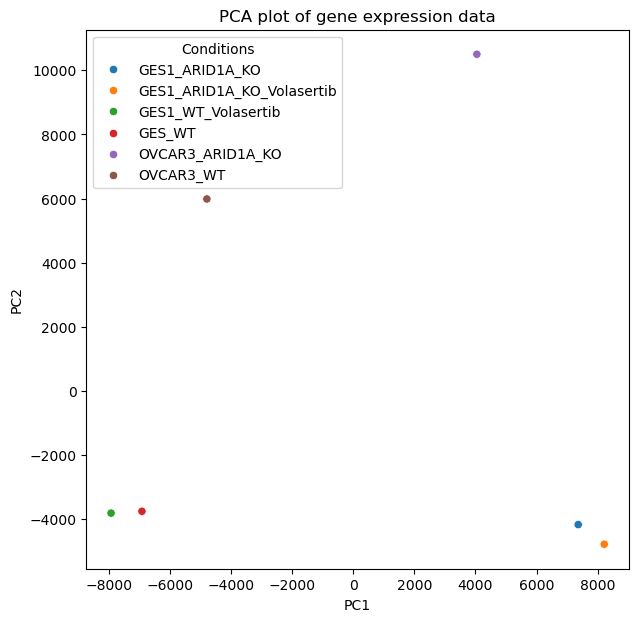

In [19]:
# Small PCA plot too

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(ge_df.T)

fig, ax = plt.subplots(figsize=(7,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=ge_df.T.index)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Conditions")
# ax.legend(bbox_to_anchor=(1.05, 1))
ax.set_title("PCA plot of gene expression data")


plt.savefig("../../results/model_evalutation/pca-gene-expression.svg", dpi=300, bbox_inches='tight')

# Model Comparisons

In [20]:
rxn_df = pl.read_csv("../../outputs/builtmodels/reaction_presence_absence matrix.csv")
# rxn_df = rxn_df.to_pandas().set_index("Reactions")

In [21]:
from scipy.spatial.distance import pdist, squareform

h:\Rajeeva\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
h:\Rajeeva\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
h:\Rajeeva\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
h:\Rajeeva\OneDrive - smail.iitm.ac.in\Projects\NUS collaboration\conda_env\Lib\site-packag

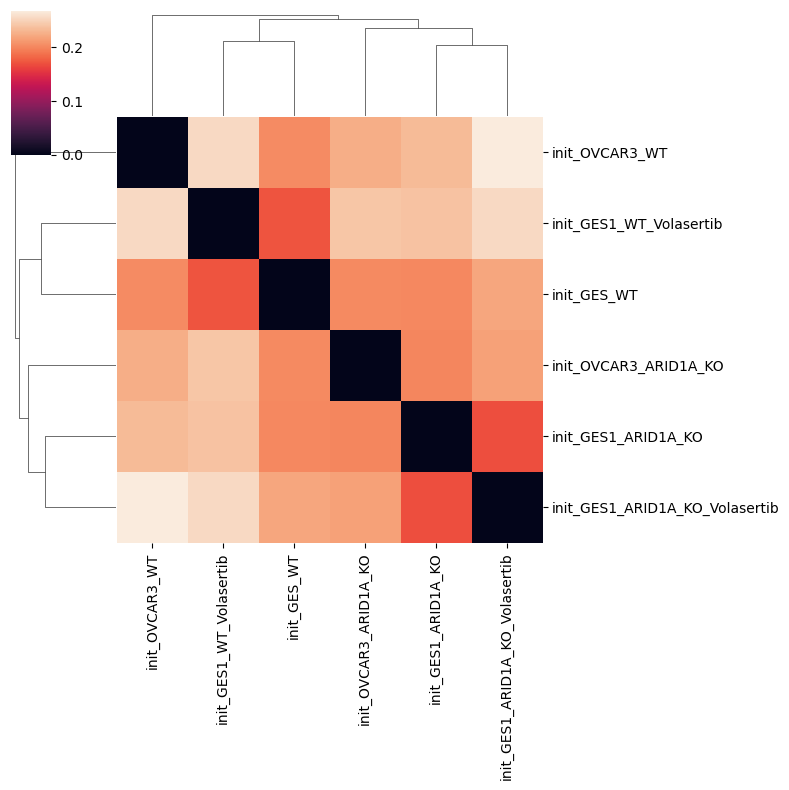

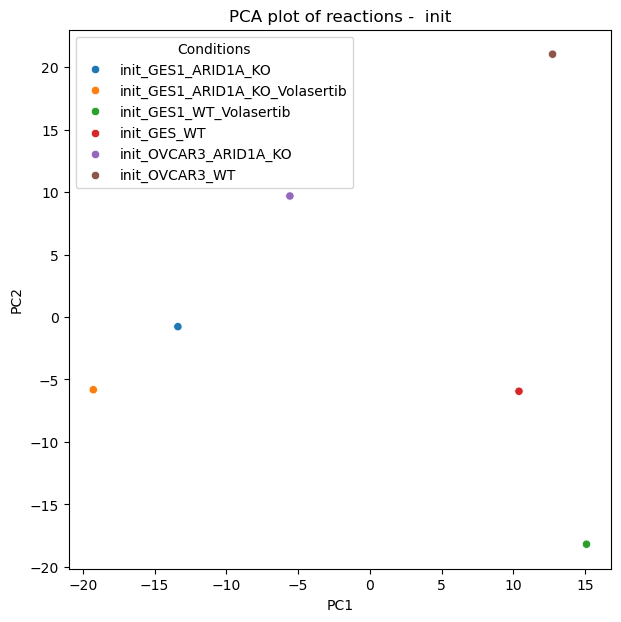

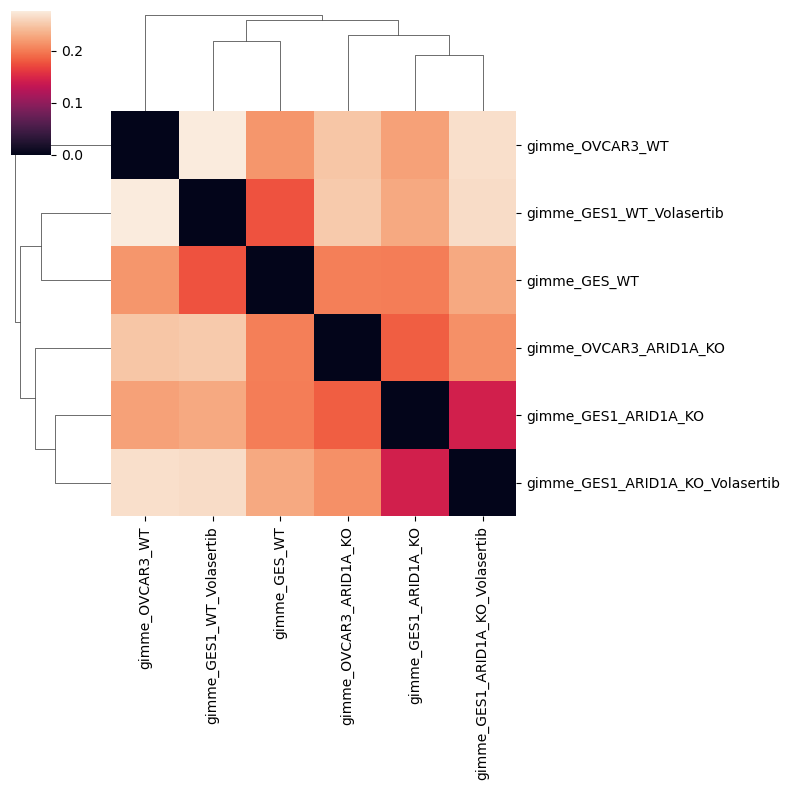

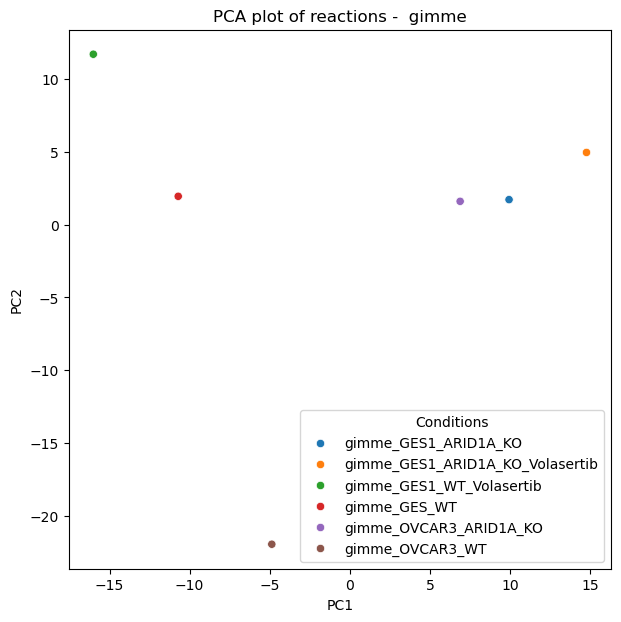

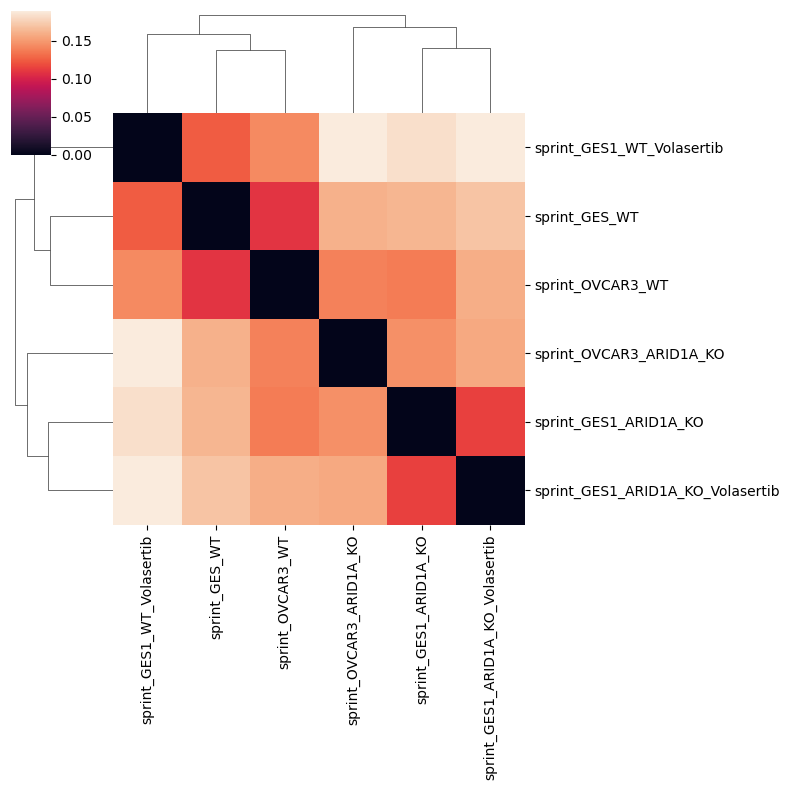

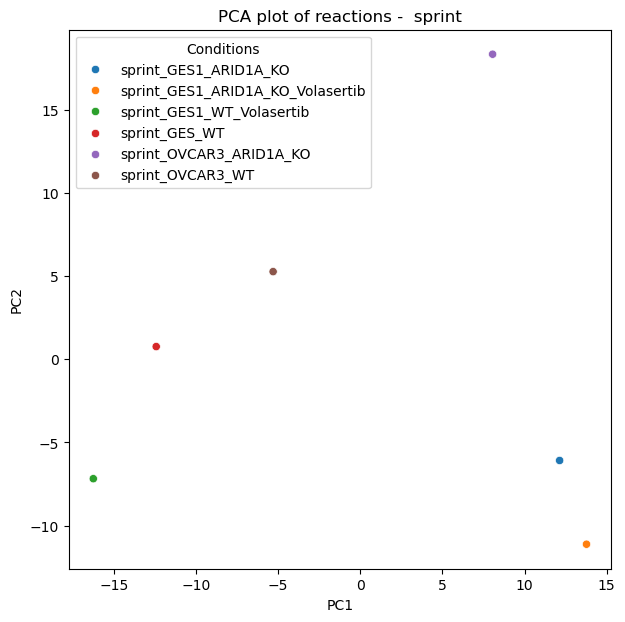

In [22]:
# fig, ax = plt.subplots(1, 3, figsize=(7,7))

for algo in ['init', 'gimme', 'sprint']:
    model_df = rxn_df.select(cs.starts_with(algo)).to_pandas()
    dist = pd.DataFrame(squareform(pdist(model_df.T, metric='jaccard')), columns=model_df.columns, index=model_df.columns)
    sns.clustermap(dist, figsize=(8,8), )
    plt.savefig(f"../../results/model_evalutation/jaccard_dist_{algo}.svg", dpi=300, bbox_inches='tight')
    
    # PCA for algorithms
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(model_df.T)

    fig, ax = plt.subplots(figsize=(7,7))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=model_df.T.index)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Conditions")
    # ax.legend(bbox_to_anchor=(1.05, 1))
    ax.set_title(f"PCA plot of reactions -  {algo}")
    
    plt.savefig(f"../../results/model_evalutation/pca-{algo}.svg", dpi=300, bbox_inches='tight')
        